In [1]:
import numpy as np
import pandas as pd
import pickle

import sklearn
import sklearn.preprocessing
import sklearn.model_selection

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import time

from matplotlib import pyplot as plt
import os
from copy import deepcopy

from models import *

In [2]:
with open('data/current.pkl', 'rb') as file:
    df_current = pickle.load(file)

with open('data/parameters.pkl', 'rb') as file:
    df_params = pickle.load(file)

In [3]:
df_params = df_params.rename(columns={"membrane": "diaphragm", "WW": "circuit function", "nominal width": "nominal width in mm", "voltage": "voltage in V", "pvor": "p_supply in bar", "prueck": "p_back in bar"})
df_params['nominal width in mm'] = df_params['nominal width in mm'].str.replace(',', '.').astype('float')
df_params['voltage in V'] = df_params['voltage in V'].astype('float')
df_params['p_supply in bar'] = df_params['p_supply in bar'].astype('float')
df_params['p_back in bar'] = df_params['p_back in bar'].astype('float')
df_params['ID'] = df_params['ID'].astype('int')

In [4]:
X = df_current.values
y = df_params['diaphragm'].copy()

In [5]:
enc = sklearn.preprocessing.OneHotEncoder(categories=[['AA', 'FF', 'CC']], sparse=False)
y_ohe = enc.fit_transform(y.values.reshape(-1, 1))
y_ohe

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [6]:
# Random Train-test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y_ohe, test_size=0.2, random_state=42)#, stratify=y_ohe)

In [7]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

In [8]:
cat_weights = torch.tensor([1.,4.,1.],dtype=torch.float32, device=device)

In [9]:
# model = PDEInspiredModel(ts_model=ValvePositionPrediction,model_channels=5)
# model = model.to(device)
# model(torch.tensor(X_train[:1],dtype=torch.float32, device=device))

In [10]:
X_fit, X_val, y_fit, y_val = sklearn.model_selection.train_test_split(X_train, y_train, test_size=0.30, random_state=123)#, stratify=y_ohe)
print(X_fit.shape)

(1210, 400)


In [11]:
# history = model.fit(X_fit, y_fit, X_val, y_val, cat_weights=cat_weights)

In [12]:
model = PDEInspiredModel(ts_model=ValvePositionPrediction,model_channels=5)
model.load_state_dict(torch.load(('./ValvePositionModel.pt')))

<All keys matched successfully>

In [13]:
# # acc = history.history['accuracy']
# val_acc = np.array(history)[:,2]
# epochs = range(1, len(val_acc) + 1)
# 
# # plt.plot(epochs, acc, 'b+')
# plt.plot(epochs, val_acc, '+',color='tab:orange')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.ylim((0.8,1))
# plt.grid()
# plt.show()

In [14]:
# loss_values = np.array(history)[:,0]
# val_loss_values = np.array(history)[:,1]
# epochs = range(1, len(loss_values) + 1)
# 
# plt.plot(epochs, loss_values, 'b+')
# plt.plot(epochs, val_loss_values, '+',color='tab:orange')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.ylim((0.,1.2))
# plt.grid()
# plt.show()

In [15]:
y_cv = model(torch.tensor(X_train, dtype=torch.float32)).detach().numpy()

In [16]:
new = np.zeros(y_cv.shape)
for i, j in enumerate(y_cv):
    new[i][np.argmax(j)] = 1

y_cv_class = new.astype('int')
y_cv_class

array([[1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       ...,
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0]])

In [17]:
# Calculate scores
r2_score_train = sklearn.metrics.r2_score(y_train, y_cv_class)
ev_score_train = sklearn.metrics.explained_variance_score(y_train, y_cv_class)
mse_train = sklearn.metrics.mean_squared_error(y_train, y_cv_class)
acc_score_train = sklearn.metrics.accuracy_score(y_train, y_cv_class)
precision_score_train_None = sklearn.metrics.precision_score(y_train, y_cv_class, average=None)
recall_score_train_None = sklearn.metrics.recall_score(y_train, y_cv_class, average=None)
precision_score_train_macro = sklearn.metrics.precision_score(y_train, y_cv_class, average='macro')
recall_score_train_macro= sklearn.metrics.recall_score(y_train, y_cv_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_train))
print(f"Precision: {np.array2string(precision_score_train_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_train_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_train_macro}")
print(f"Recall macro: {recall_score_train_macro}")

R2 Score: 0.9678
Explained variance score: 0.9678
Mean squared error: 0.0058
Accuracy Score: 0.9913
Precision: [0.9901 0.9732 0.9975]
Recall: [0.9887 0.9864 0.9950]
Precision macro: 0.9869428874171381
Recall macro: 0.9900484008014642


### Train quality

In [18]:
class_number = len(y_cv_class[0])
cm_train = np.zeros((class_number, class_number))
for tr, pre in zip(y_train, y_cv_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_train[i_true][i_pred] += 1
    
cm_train

array([[702.,   6.,   2.],
       [  3., 218.,   0.],
       [  4.,   0., 794.]])

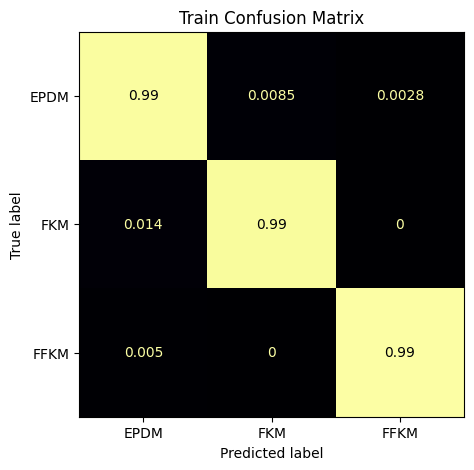

In [19]:
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_train[0] / cm_train[0].sum(), 
                                                        cm_train[1] / cm_train[1].sum(), 
                                                        cm_train[2] / cm_train[2].sum()]), 
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Train Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

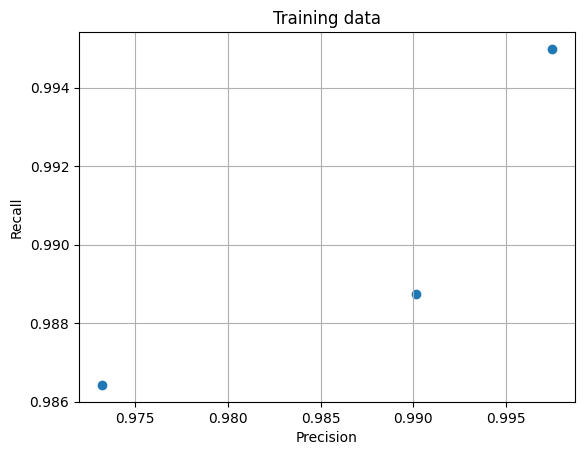

In [20]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_train_None[0],3))+'\n'+str(round(recall_score_train_None[0],3)),
     'FKM\n'+str(round(precision_score_train_None[1],3))+'\n'+str(round(recall_score_train_None[1],3)), 
     'FFKM\n'+str(round(precision_score_train_None[2],3))+'\n'+str(round(recall_score_train_None[2],3))]

ax.scatter(precision_score_train_None, recall_score_train_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Training data')

ax.annotate(n[0], (precision_score_train_None[0]+0.0015, recall_score_train_None[0]-0.009)) # EPDM
ax.annotate(n[1], (precision_score_train_None[1]+0.0015, recall_score_train_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_train_None[2]-0.008, recall_score_train_None[2]-0.011)) # FFKM
plt.show()

## Test model

In [21]:
y_predict = model(torch.tensor(X_test,dtype=torch.float32)).detach().numpy()
y_predict

array([[9.99999762e-01, 3.53938567e-09, 2.03294420e-07],
       [9.99878407e-01, 1.03871585e-04, 1.78176779e-05],
       [1.03688857e-03, 2.25297743e-04, 9.98737872e-01],
       ...,
       [1.63922695e-10, 1.75947698e-05, 9.99982357e-01],
       [3.83036677e-05, 9.99958873e-01, 2.81032499e-06],
       [1.90910043e-09, 1.94802749e-04, 9.99805272e-01]], dtype=float32)

### Test metrics

In [22]:
new = np.zeros(y_predict.shape)
for i, j in enumerate(y_predict): # enumerate, itterieren durch Liste i = index, j = Wert
    new[i][np.argmax(j)] = 1

y_predict_class = new.astype('int')
y_predict_class

array([[1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       ...,
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1]])

In [23]:
# Calculate scores
r2_score_test = sklearn.metrics.r2_score(y_test, y_predict_class)
ev_score_test = sklearn.metrics.explained_variance_score(y_test, y_predict_class)
mse_test = sklearn.metrics.mean_squared_error(y_test, y_predict_class)
acc_score_test = sklearn.metrics.accuracy_score(y_test, y_predict_class)
precision_score_test_None = sklearn.metrics.precision_score(y_test, y_predict_class, average=None)
recall_score_test_None = sklearn.metrics.recall_score(y_test, y_predict_class, average=None)
precision_score_test_macro = sklearn.metrics.precision_score(y_test, y_predict_class, average='macro')
recall_score_test_macro= sklearn.metrics.recall_score(y_test, y_predict_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_test))
print(f"Precision: {np.array2string(precision_score_test_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_test_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_test_macro}")
print(f"Recall macro: {recall_score_test_macro}")

R2 Score: 0.9678
Explained variance score: 0.9678
Mean squared error: 0.0058
Accuracy Score: 0.9885
Precision: [1.0000 0.9000 1.0000]
Recall: [0.9721 1.0000 1.0000]
Precision macro: 0.9666666666666667
Recall macro: 0.9906890130353817


### Test quality

In [24]:
class_number = len(y_predict_class[0])
cm_test = np.zeros((class_number, class_number))
for tr, pre in zip(y_test, y_predict_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_test[i_true][i_pred] += 1
    
cm_test

array([[174.,   5.,   0.],
       [  0.,  45.,   0.],
       [  0.,   0., 209.]])

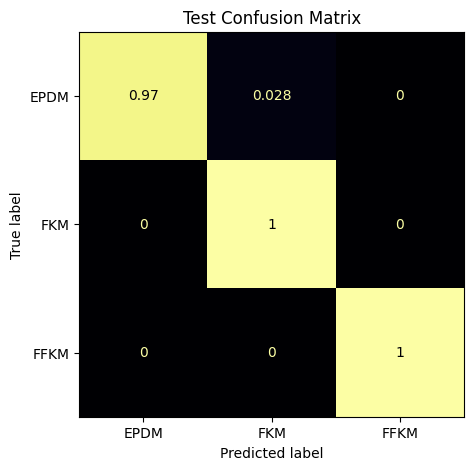

In [25]:
# sklearn.metrics.ConfusionMatrixDisplay(cm_train).plot()
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_test[0] / cm_test[0].sum(), 
                                                 cm_test[1] / cm_test[1].sum(), 
                                                 cm_test[2] / cm_test[2].sum()]),
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Test Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

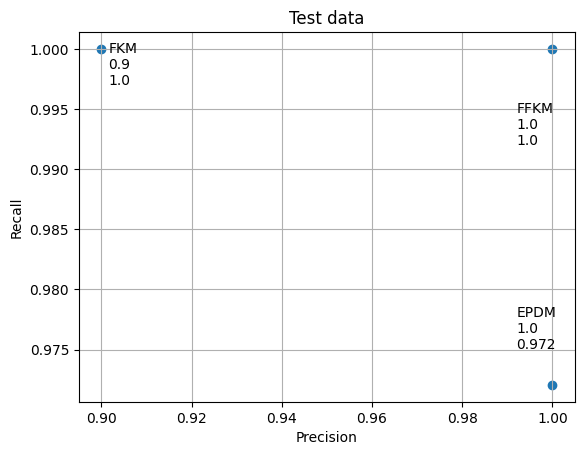

In [26]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_test_None[0],3))+'\n'+str(round(recall_score_test_None[0],3)),
     'FKM\n'+str(round(precision_score_test_None[1],3))+'\n'+str(round(recall_score_test_None[1],3)), 
     'FFKM\n'+str(round(precision_score_test_None[2],3))+'\n'+str(round(recall_score_test_None[2],3))]

ax.scatter(precision_score_test_None, recall_score_test_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Test data')

ax.annotate(n[0], (precision_score_test_None[0]-0.008, recall_score_test_None[0]+0.003)) # EPDM
ax.annotate(n[1], (precision_score_test_None[1]+0.0015, recall_score_test_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_test_None[2]-0.008, recall_score_test_None[2]-0.008)) # FFKM
plt.show()

In [27]:
# torch.save(deepcopy(model.state_dict()), 'ValvePositionModel.pt')